<a href="https://colab.research.google.com/github/adg1205/missense_mutation/blob/master/adg1205/missense_mutation/Missense_Mutation_Pathogenicity_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# 1. Install dependencies
# ============================================================
!pip -q install transformers accelerate biopython scikit-learn matplotlib pandas numpy requests tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 84.3 MB/s eta 0:00:00


In [ ]:
# ============================================================
# 2. Imports and global configuration
# ============================================================
import os
import re
import random
import urllib.request
import warnings
from collections import defaultdict

import numpy as np
import pandas as pd
import requests
import torch
from tqdm.auto import tqdm

from Bio.Align import substitution_matrices

from transformers import AutoTokenizer, AutoModel

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Fallback if you get CUDA memory errors: "facebook/esm2_t6_8M_UR50D"
MODEL_NAME = "facebook/esm2_t12_35M_UR50D"

# Mutation-centered windows keep long proteins such as BRCA1/BRCA2/CFTR manageable.
WINDOW_RADIUS = 255          # gives a max local sequence length of 511 aa
MAX_TOKENS = 1024            # ESM-2 small models support around 1024 tokens
BATCH_SIZE = 8               # reduce to 2 or 4 if Colab runs out of memory

MAX_VARIANTS_PER_CLASS_PER_GENE = 120
MAX_VUS_CASE_STUDY_VARIANTS = 60

# A compact gene panel with many known missense variants.
# Values are UniProt canonical accessions.
TARGET_PROTEINS = {
    "TP53": "P04637",
    "PTEN": "P60484",
    "LDLR": "P01130",
    "CFTR": "P13569",
    "BRCA1": "P38398",
    "BRCA2": "P51587",
    "PAH": "P00439",
    "HBB": "P68871",
    "G6PD": "P11413",
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
print("Model:", MODEL_NAME)

Device: cuda
GPU: Tesla T4
Model: facebook/esm2_t12_35M_UR50D


In [ ]:
# ============================================================
# 3. Download ClinVar variant summary
# ============================================================
CLINVAR_URL = "https://ftp.ncbi.nlm.nih.gov/pub/clinvar/tab_delimited/variant_summary.txt.gz"
CLINVAR_PATH = "/content/variant_summary.txt.gz"

if not os.path.exists(CLINVAR_PATH):
    print("Downloading ClinVar variant_summary.txt.gz ...")
    urllib.request.urlretrieve(CLINVAR_URL, CLINVAR_PATH)
else:
    print("ClinVar file already exists:", CLINVAR_PATH)

# Read only the header first so the code survives minor ClinVar column changes.
clinvar_header = pd.read_csv(CLINVAR_PATH, sep="\t", compression="gzip", nrows=0).columns.tolist()
print("Number of ClinVar columns:", len(clinvar_header))
print(clinvar_header[:12])

Number of ClinVar columns: 43
['#AlleleID', 'Type', 'Name', 'GeneID', 'GeneSymbol', 'HGNC_ID', 'ClinicalSignificance', 'ClinSigSimple', 'LastEvaluated', 'RS# (dbSNP)', 'nsv/esv (dbVar)', 'RCVaccession']


In [ ]:
# ============================================================
# 4. Helper functions for parsing ClinVar missense variants
# ============================================================

AA3_TO_1 = {
    "Ala": "A", "Arg": "R", "Asn": "N", "Asp": "D", "Cys": "C",
    "Gln": "Q", "Glu": "E", "Gly": "G", "His": "H", "Ile": "I",
    "Leu": "L", "Lys": "K", "Met": "M", "Phe": "F", "Pro": "P",
    "Ser": "S", "Thr": "T", "Trp": "W", "Tyr": "Y", "Val": "V",
}

STANDARD_AA = set(AA3_TO_1.values())

PROTEIN_CHANGE_RE = re.compile(r"p\.\(?([A-Z][a-z]{2})(\d+)([A-Z][a-z]{2})\)?")

def parse_protein_change_from_name(name):
    """Return wt_aa, position, mut_aa from ClinVar Name, or None values if not simple missense."""
    if pd.isna(name):
        return None, None, None
    m = PROTEIN_CHANGE_RE.search(str(name))
    if not m:
        return None, None, None

    wt3, pos, mut3 = m.groups()
    wt = AA3_TO_1.get(wt3)
    mut = AA3_TO_1.get(mut3)

    if wt is None or mut is None:
        return None, None, None
    if wt == mut:
        return None, None, None

    return wt, int(pos), mut


def clinical_significance_to_label(sig):
    """
    Convert ClinVar clinical significance into binary label.
    Pathogenic / likely pathogenic -> 1
    Benign / likely benign -> 0
    Others, including VUS/conflicting -> None
    """
    if pd.isna(sig):
        return None

    s = str(sig).lower()

    # Remove ambiguous labels from training.
    ambiguous_terms = [
        "uncertain",
        "conflicting",
        "not provided",
        "association",
        "risk factor",
        "drug response",
        "protective",
        "affects",
        "other",
    ]
    if any(term in s for term in ambiguous_terms):
        return None

    has_path = "pathogenic" in s
    has_benign = "benign" in s

    if has_path and not has_benign:
        return 1
    if has_benign and not has_path:
        return 0
    return None


def is_vus_like(sig):
    if pd.isna(sig):
        return False
    s = str(sig).lower()
    return "uncertain" in s or "conflicting" in s


def read_target_clinvar_variants(clinvar_path, target_genes, chunksize=250_000):
    """Stream ClinVar and keep only parsed missense variants from target genes."""

    needed = [
        "#AlleleID", "Type", "Name", "GeneID", "GeneSymbol",
        "ClinicalSignificance", "ClinSigSimple", "Assembly",
        "ReviewStatus", "VariationID", "PhenotypeList",
    ]
    available = [c for c in needed if c in clinvar_header]

    frames = []
    target_genes = set(target_genes)

    reader = pd.read_csv(
        clinvar_path,
        sep="\t",
        compression="gzip",
        dtype=str,
        usecols=available,
        chunksize=chunksize,
        low_memory=False,
    )

    for chunk in tqdm(reader, desc="Filtering ClinVar chunks"):
        if "GeneSymbol" not in chunk.columns or "Name" not in chunk.columns:
            raise ValueError("ClinVar file is missing GeneSymbol or Name column.")

        chunk = chunk[chunk["GeneSymbol"].isin(target_genes)].copy()

        if "Assembly" in chunk.columns:
            chunk = chunk[chunk["Assembly"].eq("GRCh38")].copy()

        if "Type" in chunk.columns:
            chunk = chunk[chunk["Type"].str.lower().eq("single nucleotide variant")].copy()

        if chunk.empty:
            continue

        parsed = chunk["Name"].apply(parse_protein_change_from_name)
        chunk["wt_aa"] = parsed.apply(lambda x: x[0])
        chunk["position"] = parsed.apply(lambda x: x[1])
        chunk["mut_aa"] = parsed.apply(lambda x: x[2])

        chunk = chunk.dropna(subset=["wt_aa", "position", "mut_aa"]).copy()
        if chunk.empty:
            continue

        chunk["position"] = chunk["position"].astype(int)
        chunk["label"] = chunk["ClinicalSignificance"].apply(clinical_significance_to_label)
        chunk["is_vus_like"] = chunk["ClinicalSignificance"].apply(is_vus_like)

        frames.append(chunk)

    if not frames:
        raise RuntimeError("No target missense variants were found. Try adding more target genes.")

    df = pd.concat(frames, ignore_index=True)

    # Deduplicate repeated variant-condition rows.
    dedupe_cols = ["GeneSymbol", "position", "wt_aa", "mut_aa", "label"]
    df = df.drop_duplicates(subset=dedupe_cols).reset_index(drop=True)

    return df


clinvar_variants = read_target_clinvar_variants(CLINVAR_PATH, TARGET_PROTEINS.keys())

print("Parsed target missense variants:", len(clinvar_variants))
display(clinvar_variants[[
    "GeneSymbol", "Name", "ClinicalSignificance", "wt_aa", "position", "mut_aa", "label", "is_vus_like"
]].head())

print("\nLabel counts before sequence verification:")
print(clinvar_variants["label"].value_counts(dropna=False))

Filtering ClinVar chunks: 0it [00:00, ?it/s]

Parsed target missense variants: 23552


,GeneSymbol,Name,ClinicalSignificance,wt_aa,position,mut_aa,label,is_vus_like
0,PAH,NM_000277.3(PAH):c.1222C>T (p.Arg408Trp),Pathogenic,R,408,W,1.0,False
1,PAH,NM_000277.3(PAH):c.932T>C (p.Leu311Pro),Pathogenic,L,311,P,1.0,False
2,PAH,NM_000277.3(PAH):c.838G>A (p.Glu280Lys),Pathogenic,E,280,K,1.0,False
3,PAH,NM_000277.3(PAH):c.782G>A (p.Arg261Gln),Pathogenic,R,261,Q,1.0,False
4,PAH,NM_000277.3(PAH):c.261C>A (p.Ser87Arg),Pathogenic/Likely pathogenic,S,87,R,1.0,False



Label counts before sequence verification:
label
NaN    19875
1.0     2495
0.0     1182
Name: count, dtype: int64


In [ ]:
# ============================================================
# 5. Balance the labeled training set and keep VUS-like variants separately
# ============================================================

labeled_raw = clinvar_variants[clinvar_variants["label"].notna()].copy()
labeled_raw["label"] = labeled_raw["label"].astype(int)

vus_raw = clinvar_variants[
    clinvar_variants["label"].isna() & clinvar_variants["is_vus_like"]
].copy()

def sample_per_gene_class(df, max_n=120, seed=42):
    parts = []
    for (gene, label), group in df.groupby(["GeneSymbol", "label"]):
        n = min(len(group), max_n)
        parts.append(group.sample(n=n, random_state=seed))
    return pd.concat(parts, ignore_index=True)

labeled_sample = sample_per_gene_class(
    labeled_raw,
    max_n=MAX_VARIANTS_PER_CLASS_PER_GENE,
    seed=SEED,
)

print("Labeled sample size:", len(labeled_sample))
print(labeled_sample.groupby(["GeneSymbol", "label"]).size())

print("\nVUS-like candidates before verification:", len(vus_raw))

Labeled sample size: 1471
GeneSymbol  label
BRCA1       0        120
            1        120
BRCA2       0        120
            1        105
CFTR        0         15
            1        120
G6PD        0          4
            1        120
HBB         0         18
            1         81
LDLR        0         40
            1        120
PAH         0          1
            1        120
PTEN        0          7
            1        120
TP53        0        120
            1        120
dtype: int64

VUS-like candidates before verification: 18580


In [ ]:
# ============================================================
# 6. Download UniProt protein sequence + feature annotations
# ============================================================

def fetch_uniprot_json(accession):
    url = f"https://rest.uniprot.org/uniprotkb/{accession}.json"
    r = requests.get(url, timeout=60)
    r.raise_for_status()
    return r.json()


def extract_uniprot_intervals(uniprot_json):
    """Extract protein feature intervals from UniProt JSON."""
    intervals = []
    for feat in uniprot_json.get("features", []):
        ftype = feat.get("type", "Unknown")
        desc = feat.get("description", "")

        loc = feat.get("location", {})
        start_obj = loc.get("start", {})
        end_obj = loc.get("end", {})

        start = start_obj.get("value")
        end = end_obj.get("value")

        if start is None or end is None:
            continue

        try:
            start, end = int(start), int(end)
        except Exception:
            continue

        intervals.append({
            "type": ftype,
            "description": desc,
            "start": start,
            "end": end,
        })
    return intervals


protein_info = {}

for gene, acc in TARGET_PROTEINS.items():
    print(f"Fetching UniProt: {gene} -> {acc}")
    js = fetch_uniprot_json(acc)
    sequence = js["sequence"]["value"]
    features = extract_uniprot_intervals(js)
    protein_info[gene] = {
        "accession": acc,
        "sequence": sequence,
        "length": len(sequence),
        "features": features,
    }

pd.DataFrame([
    {
        "GeneSymbol": gene,
        "UniProt": info["accession"],
        "Length": info["length"],
        "Num_features": len(info["features"]),
    }
    for gene, info in protein_info.items()
])

Fetching UniProt: TP53 -> P04637
Fetching UniProt: PTEN -> P60484
Fetching UniProt: LDLR -> P01130
Fetching UniProt: CFTR -> P13569
Fetching UniProt: BRCA1 -> P38398
Fetching UniProt: BRCA2 -> P51587
Fetching UniProt: PAH -> P00439
Fetching UniProt: HBB -> P68871
Fetching UniProt: G6PD -> P11413


,GeneSymbol,UniProt,Length,Num_features
0,TP53,P04637,393,1518
1,PTEN,P60484,403,178
2,LDLR,P01130,860,394
3,CFTR,P13569,1480,393
4,BRCA1,P38398,1863,313
5,BRCA2,P51587,3418,213
6,PAH,P00439,452,259
7,HBB,P68871,147,325
8,G6PD,P11413,515,172


In [ ]:
# ============================================================
# 7. Protein feature engineering helpers
# ============================================================

blosum62 = substitution_matrices.load("BLOSUM62")

HYDROPATHY = {
    "A": 1.8,  "R": -4.5, "N": -3.5, "D": -3.5, "C": 2.5,
    "Q": -3.5, "E": -3.5, "G": -0.4, "H": -3.2, "I": 4.5,
    "L": 3.8,  "K": -3.9, "M": 1.9,  "F": 2.8,  "P": -1.6,
    "S": -0.8, "T": -0.7, "W": -0.9, "Y": -1.3, "V": 4.2,
}

AA_MASS = {
    "A": 89.09,  "R": 174.20, "N": 132.12, "D": 133.10, "C": 121.15,
    "Q": 146.15, "E": 147.13, "G": 75.07,  "H": 155.16, "I": 131.17,
    "L": 131.17, "K": 146.19, "M": 149.21, "F": 165.19, "P": 115.13,
    "S": 105.09, "T": 119.12, "W": 204.23, "Y": 181.19, "V": 117.15,
}

CHARGE_CLASS = {
    "D": "negative", "E": "negative",
    "K": "positive", "R": "positive", "H": "positive",
}

DOMAIN_LIKE_TYPES = {
    "Domain", "Repeat", "Zinc finger", "DNA binding",
    "Nucleotide binding", "Region", "Compositional bias",
}

ACTIVE_BINDING_TYPES = {
    "Active site", "Binding site", "Site", "Metal binding",
    "Calcium binding", "Modified residue",
}

MEMBRANE_TYPES = {
    "Transmembrane", "Topological domain", "Intramembrane",
}


def blosum_score(a, b):
    try:
        return float(blosum62[a, b])
    except Exception:
        try:
            return float(blosum62[b, a])
        except Exception:
            return np.nan


def charge_group(aa):
    return CHARGE_CLASS.get(aa, "neutral")


def feature_flags_at_position(intervals, pos):
    covering = [f for f in intervals if f["start"] <= pos <= f["end"]]
    covering_types = {f["type"] for f in covering}

    return {
        "in_any_uniprot_feature": int(len(covering) > 0),
        "in_domain_like_feature": int(len(covering_types & DOMAIN_LIKE_TYPES) > 0),
        "in_active_or_binding_feature": int(len(covering_types & ACTIVE_BINDING_TYPES) > 0),
        "in_membrane_feature": int(len(covering_types & MEMBRANE_TYPES) > 0),
        "uniprot_feature_count": len(covering),
        "covering_feature_types": ";".join(sorted(covering_types)),
    }


def make_mutation_window(sequence, pos, wt_aa, mut_aa, radius=255):
    """
    Build local wild-type and mutant sequence windows around a 1-based mutation position.
    Returns wt_window, mut_window, local_pos, window_start, window_end.
    """
    pos = int(pos)
    if sequence[pos - 1] != wt_aa:
        raise ValueError(f"WT mismatch at position {pos}: sequence has {sequence[pos-1]}, expected {wt_aa}")

    start = max(1, pos - radius)
    end = min(len(sequence), pos + radius)

    wt_window = sequence[start - 1:end]
    local_pos = pos - start + 1

    mut_list = list(wt_window)
    mut_list[local_pos - 1] = mut_aa
    mut_window = "".join(mut_list)

    return wt_window, mut_window, local_pos, start, end


def annotate_variants_with_sequence_and_uniprot(df, protein_info, radius=255):
    """Verify canonical sequence coordinates, build windows, and add protein/domain features."""

    rows = []
    mismatch_count = 0
    out_of_range_count = 0

    for _, row in tqdm(df.iterrows(), total=len(df), desc="Verifying sequence positions"):
        gene = row["GeneSymbol"]
        if gene not in protein_info:
            continue

        seq = protein_info[gene]["sequence"]
        pos = int(row["position"])
        wt = row["wt_aa"]
        mut = row["mut_aa"]

        if pos < 1 or pos > len(seq):
            out_of_range_count += 1
            continue

        if seq[pos - 1] != wt:
            mismatch_count += 1
            continue

        wt_window, mut_window, local_pos, win_start, win_end = make_mutation_window(
            sequence=seq,
            pos=pos,
            wt_aa=wt,
            mut_aa=mut,
            radius=radius,
        )

        flags = feature_flags_at_position(protein_info[gene]["features"], pos)

        new_row = row.to_dict()
        new_row.update({
            "uniprot_accession": protein_info[gene]["accession"],
            "protein_length": len(seq),
            "norm_position": pos / len(seq),
            "wt_window": wt_window,
            "mut_window": mut_window,
            "local_pos": local_pos,
            "window_start": win_start,
            "window_end": win_end,
            "window_length": len(wt_window),
            "blosum62": blosum_score(wt, mut),
            "hydropathy_delta": HYDROPATHY[mut] - HYDROPATHY[wt],
            "abs_hydropathy_delta": abs(HYDROPATHY[mut] - HYDROPATHY[wt]),
            "mass_delta": AA_MASS[mut] - AA_MASS[wt],
            "abs_mass_delta": abs(AA_MASS[mut] - AA_MASS[wt]),
            "charge_changed": int(charge_group(wt) != charge_group(mut)),
            "to_proline": int(mut == "P"),
            "from_glycine": int(wt == "G"),
            "to_glycine": int(mut == "G"),
        })
        new_row.update(flags)
        rows.append(new_row)

    verified = pd.DataFrame(rows)

    print("Kept variants:", len(verified))
    print("Dropped due to WT mismatch:", mismatch_count)
    print("Dropped due to out-of-range position:", out_of_range_count)

    return verified


labeled_verified = annotate_variants_with_sequence_and_uniprot(
    labeled_sample,
    protein_info,
    radius=WINDOW_RADIUS,
)

print("\nVerified labeled data shape:", labeled_verified.shape)
print(labeled_verified.groupby(["GeneSymbol", "label"]).size())
display(labeled_verified.head())

Verifying sequence positions:   0%|          | 0/1471 [00:00<?, ?it/s]

Kept variants: 1441
Dropped due to WT mismatch: 30
Dropped due to out-of-range position: 0

Verified labeled data shape: (1441, 40)
GeneSymbol  label
BRCA1       0        120
            1        120
BRCA2       0        120
            1        105
CFTR        0         15
            1        120
G6PD        0          4
            1         90
HBB         0         18
            1         81
LDLR        0         40
            1        120
PAH         0          1
            1        120
PTEN        0          7
            1        120
TP53        0        120
            1        120
dtype: int64


,#AlleleID,Type,Name,GeneID,GeneSymbol,ClinicalSignificance,ClinSigSimple,PhenotypeList,Assembly,ReviewStatus,...,charge_changed,to_proline,from_glycine,to_glycine,in_any_uniprot_feature,in_domain_like_feature,in_active_or_binding_feature,in_membrane_feature,uniprot_feature_count,covering_feature_types
0,1786280,single nucleotide variant,NM_007294.4(BRCA1):c.3550G>A (p.Gly1184Arg),672,BRCA1,Likely benign,0,Hereditary cancer-predisposing syndrome,GRCh38,"criteria provided, multiple submitters, no con...",...,1,0,1,0,1,1,0,0,6,Alternative sequence;Chain;Natural variant;Region
1,46171,single nucleotide variant,NM_007294.4(BRCA1):c.4955T>C (p.Met1652Thr),672,BRCA1,Benign,0,"Breast-ovarian cancer, familial, susceptibilit...",GRCh38,reviewed by expert panel,...,0,0,0,0,1,1,0,0,6,Alternative sequence;Beta strand;Chain;Domain;...
2,46035,single nucleotide variant,NM_007294.4(BRCA1):c.2669G>T (p.Gly890Val),672,BRCA1,Benign,0,"Breast-ovarian cancer, familial, susceptibilit...",GRCh38,reviewed by expert panel,...,0,0,1,0,1,0,0,0,4,Alternative sequence;Chain
3,1038578,single nucleotide variant,NM_007294.4(BRCA1):c.1240G>T (p.Asp414Tyr),672,BRCA1,Likely benign,0,not provided|Hereditary cancer-predisposing sy...,GRCh38,"criteria provided, single submitter",...,1,0,0,0,1,0,0,0,4,Alternative sequence;Chain
4,50264,single nucleotide variant,NM_007294.4(BRCA1):c.4520G>C (p.Arg1507Thr),672,BRCA1,Benign,0,not provided|Hereditary breast ovarian cancer ...,GRCh38,reviewed by expert panel,...,1,0,0,0,1,0,0,0,3,Alternative sequence;Chain;Natural variant


In [ ]:
# ============================================================
# 8. Load ESM-2 model
# ============================================================

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
esm_model = AutoModel.from_pretrained(MODEL_NAME)
esm_model.to(device)
esm_model.eval()

print("Loaded:", MODEL_NAME)
print("Hidden size:", esm_model.config.hidden_size)

config.json:   0%|          | 0.00/778 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/136M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/209 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t12_35M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
pooler.dense.bias           | MISSING    | 
pooler.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loaded: facebook/esm2_t12_35M_UR50D
Hidden size: 480


In [ ]:
# ============================================================
# 9. ESM-2 embedding extraction
# ============================================================

def embed_sequence_windows(sequences, local_positions, batch_size=8):
    """
    Return mean-pooled and mutation-site embeddings for each sequence window.

    For ESM tokenization:
    token index 0 is a special token.
    sequence residue i, using 1-based local position, is token index i.
    """
    mean_embeddings = []
    site_embeddings = []

    for start in tqdm(range(0, len(sequences), batch_size), desc="ESM embedding batches"):
        batch_seqs = list(sequences[start:start + batch_size])
        batch_pos = list(local_positions[start:start + batch_size])

        enc = tokenizer(
            batch_seqs,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=MAX_TOKENS,
        )
        enc = {k: v.to(device) for k, v in enc.items()}

        with torch.no_grad():
            outputs = esm_model(**enc)
            hidden = outputs.last_hidden_state.detach().cpu()

        for j, seq in enumerate(batch_seqs):
            # Exclude special tokens; use only residue embeddings.
            L = min(len(seq), MAX_TOKENS - 2)
            residue_embeddings = hidden[j, 1:L + 1, :]
            mean_emb = residue_embeddings.mean(dim=0).numpy()

            site_index = min(int(batch_pos[j]), L)
            site_emb = hidden[j, site_index, :].numpy()

            mean_embeddings.append(mean_emb)
            site_embeddings.append(site_emb)

    return np.vstack(mean_embeddings), np.vstack(site_embeddings)


def cosine_distance(a, b):
    denom = (np.linalg.norm(a) * np.linalg.norm(b)) + 1e-12
    return 1.0 - float(np.dot(a, b) / denom)


def add_esm_change_features(df, cache_prefix="/content/labeled"):
    """Compute WT-vs-mutant ESM embedding-change features."""
    df = df.reset_index(drop=True).copy()

    cache_csv = f"{cache_prefix}_with_esm_features.csv"
    if os.path.exists(cache_csv):
        print("Loading cached ESM features:", cache_csv)
        return pd.read_csv(cache_csv)

    n = len(df)

    all_sequences = df["wt_window"].tolist() + df["mut_window"].tolist()
    all_positions = df["local_pos"].tolist() + df["local_pos"].tolist()

    mean_embs, site_embs = embed_sequence_windows(
        all_sequences,
        all_positions,
        batch_size=BATCH_SIZE,
    )

    wt_mean = mean_embs[:n]
    mut_mean = mean_embs[n:]
    wt_site = site_embs[:n]
    mut_site = site_embs[n:]

    mean_cos = []
    mean_l2 = []
    site_cos = []
    site_l2 = []
    site_abs_delta_mean = []
    mean_abs_delta_mean = []

    for i in range(n):
        mean_cos.append(cosine_distance(wt_mean[i], mut_mean[i]))
        mean_l2.append(float(np.linalg.norm(mut_mean[i] - wt_mean[i])))

        site_cos.append(cosine_distance(wt_site[i], mut_site[i]))
        site_l2.append(float(np.linalg.norm(mut_site[i] - wt_site[i])))

        site_abs_delta_mean.append(float(np.mean(np.abs(mut_site[i] - wt_site[i]))))
        mean_abs_delta_mean.append(float(np.mean(np.abs(mut_mean[i] - wt_mean[i]))))

    df["esm_mean_cosine_distance"] = mean_cos
    df["esm_mean_l2_distance"] = mean_l2
    df["esm_site_cosine_distance"] = site_cos
    df["esm_site_l2_distance"] = site_l2
    df["esm_site_abs_delta_mean"] = site_abs_delta_mean
    df["esm_mean_abs_delta_mean"] = mean_abs_delta_mean

    df.to_csv(cache_csv, index=False)
    print("Saved:", cache_csv)

    return df


features_df = add_esm_change_features(labeled_verified, cache_prefix="/content/labeled")

print("Final feature table:", features_df.shape)
display(features_df.head())

ESM embedding batches:   0%|          | 0/361 [00:00<?, ?it/s]

Saved: /content/labeled_with_esm_features.csv
Final feature table: (1441, 46)


,#AlleleID,Type,Name,GeneID,GeneSymbol,ClinicalSignificance,ClinSigSimple,PhenotypeList,Assembly,ReviewStatus,...,in_active_or_binding_feature,in_membrane_feature,uniprot_feature_count,covering_feature_types,esm_mean_cosine_distance,esm_mean_l2_distance,esm_site_cosine_distance,esm_site_l2_distance,esm_site_abs_delta_mean,esm_mean_abs_delta_mean
0,1786280,single nucleotide variant,NM_007294.4(BRCA1):c.3550G>A (p.Gly1184Arg),672,BRCA1,Likely benign,0,Hereditary cancer-predisposing syndrome,GRCh38,"criteria provided, multiple submitters, no con...",...,0,0,6,Alternative sequence;Chain;Natural variant;Region,0.000075,0.081944,0.187891,4.727397,0.170955,0.002942
1,46171,single nucleotide variant,NM_007294.4(BRCA1):c.4955T>C (p.Met1652Thr),672,BRCA1,Benign,0,"Breast-ovarian cancer, familial, susceptibilit...",GRCh38,reviewed by expert panel,...,0,0,6,Alternative sequence;Beta strand;Chain;Domain;...,0.000021,0.039055,0.101068,3.542522,0.127129,0.001413
2,46035,single nucleotide variant,NM_007294.4(BRCA1):c.2669G>T (p.Gly890Val),672,BRCA1,Benign,0,"Breast-ovarian cancer, familial, susceptibilit...",GRCh38,reviewed by expert panel,...,0,0,4,Alternative sequence;Chain,0.000039,0.059597,0.201710,4.918968,0.176607,0.002134
3,1038578,single nucleotide variant,NM_007294.4(BRCA1):c.1240G>T (p.Asp414Tyr),672,BRCA1,Likely benign,0,not provided|Hereditary cancer-predisposing sy...,GRCh38,"criteria provided, single submitter",...,0,0,4,Alternative sequence;Chain,0.000051,0.068212,0.135908,4.002131,0.146484,0.002452
4,50264,single nucleotide variant,NM_007294.4(BRCA1):c.4520G>C (p.Arg1507Thr),672,BRCA1,Benign,0,not provided|Hereditary breast ovarian cancer ...,GRCh38,reviewed by expert panel,...,0,0,3,Alternative sequence;Chain;Natural variant,0.000057,0.068076,0.146387,4.171762,0.151219,0.002465


In [ ]:
# ============================================================
# 10.A Train/test split and model comparison
# ============================================================

bio_domain_features = [
    "norm_position",
    "protein_length",
    "window_length",
    "blosum62",
    "hydropathy_delta",
    "abs_hydropathy_delta",
    "mass_delta",
    "abs_mass_delta",
    "charge_changed",
    "to_proline",
    "from_glycine",
    "to_glycine",
    "in_any_uniprot_feature",
    "in_domain_like_feature",
    "in_active_or_binding_feature",
    "in_membrane_feature",
    "uniprot_feature_count",
]

esm_features = [
    "esm_mean_cosine_distance",
    "esm_mean_l2_distance",
    "esm_site_cosine_distance",
    "esm_site_l2_distance",
    "esm_site_abs_delta_mean",
    "esm_mean_abs_delta_mean",
]

all_features = bio_domain_features + esm_features

# Keep rows with valid labels.
model_df = features_df.dropna(subset=["label"]).copy()
model_df["label"] = model_df["label"].astype(int)

X = model_df[all_features].copy()
y = model_df["label"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=SEED,
)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Train label balance:")
print(y_train.value_counts(normalize=True))
print("Test label balance:")
print(y_test.value_counts(normalize=True))


def build_logreg():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            random_state=SEED,
        )),
    ])


def build_rf():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=SEED,
            n_jobs=-1,
        )),
    ])


def evaluate_model(model_name, feature_cols, estimator):
    estimator.fit(X_train[feature_cols], y_train)

    pred = estimator.predict(X_test[feature_cols])
    if hasattr(estimator, "predict_proba"):
        prob = estimator.predict_proba(X_test[feature_cols])[:, 1]
    else:
        prob = pred

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test,
        pred,
        average="binary",
        zero_division=0,
    )

    result = {
        "model_name": model_name,
        "n_features": len(feature_cols),
        "accuracy": accuracy_score(y_test, pred),
        "precision_pathogenic": precision,
        "recall_pathogenic": recall,
        "f1_pathogenic": f1,
        "roc_auc": roc_auc_score(y_test, prob),
    }

    return estimator, result


experiments = [
    ("Bio/domain only | LogisticRegression", bio_domain_features, build_logreg()),
    ("ESM only | LogisticRegression", esm_features, build_logreg()),
    ("ESM + bio/domain | LogisticRegression", all_features, build_logreg()),
    ("Bio/domain only | RandomForest", bio_domain_features, build_rf()),
    ("ESM only | RandomForest", esm_features, build_rf()),
    ("ESM + bio/domain | RandomForest", all_features, build_rf()),
]

trained_models = {}
results = []

for name, cols, estimator in experiments:
    fitted, result = evaluate_model(name, cols, estimator)
    trained_models[name] = {
        "model": fitted,
        "features": cols,
        "result": result,
    }
    results.append(result)

results_df = pd.DataFrame(results)

# Select the best model using a practical pathogenicity-screening score.
# This favors the model that performs best on accuracy, pathogenic recall, and F1-score.
selection_metrics = [
    "accuracy",
    "recall_pathogenic",
    "f1_pathogenic",
]

results_df["selection_score"] = results_df[selection_metrics].mean(axis=1)

# Sort by practical score first.
# If two models tie, use ROC-AUC as the secondary tie-breaker.
results_df = results_df.sort_values(
    ["selection_score", "roc_auc"],
    ascending=[False, False]
)

display(results_df)
results_df.to_csv("/content/model_comparison_results.csv", index=False)

best_name = results_df.iloc[0]["model_name"]
best_model = trained_models[best_name]["model"]
best_features = trained_models[best_name]["features"]

print("Best model selected using practical screening score:", best_name)
print("Selection metrics used:", selection_metrics)
print("Features used:", best_features)

Train: (1080, 23) Test: (361, 23)
Train label balance:
label
1    0.690741
0    0.309259
Name: proportion, dtype: float64
Test label balance:
label
1    0.692521
0    0.307479
Name: proportion, dtype: float64


,model_name,n_features,accuracy,precision_pathogenic,recall_pathogenic,f1_pathogenic,roc_auc,selection_score
5,ESM + bio/domain | RandomForest,23,0.844875,0.841549,0.956,0.895131,0.887099,0.898669
3,Bio/domain only | RandomForest,17,0.831025,0.846154,0.924,0.883365,0.900036,0.879463
4,ESM only | RandomForest,6,0.745152,0.772414,0.896,0.829630,0.744577,0.823594
2,ESM + bio/domain | LogisticRegression,23,0.714681,0.835616,0.732,0.780384,0.790811,0.742355
0,Bio/domain only | LogisticRegression,17,0.678670,0.819048,0.688,0.747826,0.740937,0.704832
1,ESM only | LogisticRegression,6,0.686981,0.840796,0.676,0.749446,0.752577,0.704142


Best model selected using practical screening score: ESM + bio/domain | RandomForest
Selection metrics used: ['accuracy', 'recall_pathogenic', 'f1_pathogenic']
Features used: ['norm_position', 'protein_length', 'window_length', 'blosum62', 'hydropathy_delta', 'abs_hydropathy_delta', 'mass_delta', 'abs_mass_delta', 'charge_changed', 'to_proline', 'from_glycine', 'to_glycine', 'in_any_uniprot_feature', 'in_domain_like_feature', 'in_active_or_binding_feature', 'in_membrane_feature', 'uniprot_feature_count', 'esm_mean_cosine_distance', 'esm_mean_l2_distance', 'esm_site_cosine_distance', 'esm_site_l2_distance', 'esm_site_abs_delta_mean', 'esm_mean_abs_delta_mean']


In [ ]:
# ============================================================
# 10B. Hyperparameter Sensitivity + Learning/Convergence Curves
# ============================================================

from sklearn.model_selection import train_test_split, StratifiedKFold, learning_curve
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# A. Create internal train/validation split from the training set
# ------------------------------------------------------------
# The original test set remains untouched.
# Hyperparameter checks are done using train_core and validation set.

X_train_core, X_val, y_train_core, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    stratify=y_train,
    random_state=SEED,
)

print("Train-core:", X_train_core.shape)
print("Validation:", X_val.shape)
print("Held-out test:", X_test.shape)


# ------------------------------------------------------------
# B. Helper evaluation function
# ------------------------------------------------------------

def evaluate_on_split(estimator, feature_cols, X_tr, y_tr, X_ev, y_ev):
    estimator.fit(X_tr[feature_cols], y_tr)

    pred = estimator.predict(X_ev[feature_cols])

    if hasattr(estimator, "predict_proba"):
        prob = estimator.predict_proba(X_ev[feature_cols])[:, 1]
    else:
        prob = pred

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_ev,
        pred,
        average="binary",
        zero_division=0,
    )

    return {
        "accuracy": accuracy_score(y_ev, pred),
        "precision_pathogenic": precision,
        "recall_pathogenic": recall,
        "f1_pathogenic": f1,
        "roc_auc": roc_auc_score(y_ev, prob),
    }


# ------------------------------------------------------------
# C. Feature-set definitions
# ------------------------------------------------------------

feature_sets = {
    "Bio/domain only": bio_domain_features,
    "ESM only": esm_features,
    "ESM + bio/domain": all_features,
}


# ------------------------------------------------------------
# D. Hyperparameter sensitivity for Logistic Regression
# ------------------------------------------------------------
# Hyperparameter varied: C
# C controls regularization strength.
# Smaller C = stronger regularization.
# Larger C = weaker regularization.

logreg_C_values = [0.01, 0.1, 1.0, 10.0]

hyperparam_results = []

for feature_set_name, feature_cols in feature_sets.items():
    for C_value in logreg_C_values:

        estimator = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(
                C=C_value,
                max_iter=3000,
                class_weight="balanced",
                random_state=SEED,
            )),
        ])

        val_metrics = evaluate_on_split(
            estimator,
            feature_cols,
            X_train_core,
            y_train_core,
            X_val,
            y_val,
        )

        row = {
            "algorithm": "LogisticRegression",
            "feature_set": feature_set_name,
            "hyperparameter": "C",
            "hyperparameter_value": C_value,
            **val_metrics,
        }

        hyperparam_results.append(row)


# ------------------------------------------------------------
# E. Hyperparameter sensitivity for RandomForest
# ------------------------------------------------------------
# Hyperparameter varied: n_estimators
# n_estimators = number of trees in the forest.

rf_n_estimators_values = [100, 200, 300, 500]

for feature_set_name, feature_cols in feature_sets.items():
    for n_tree in rf_n_estimators_values:

        estimator = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("clf", RandomForestClassifier(
                n_estimators=n_tree,
                max_depth=None,
                min_samples_leaf=2,
                class_weight="balanced",
                random_state=SEED,
                n_jobs=-1,
            )),
        ])

        val_metrics = evaluate_on_split(
            estimator,
            feature_cols,
            X_train_core,
            y_train_core,
            X_val,
            y_val,
        )

        row = {
            "algorithm": "RandomForest",
            "feature_set": feature_set_name,
            "hyperparameter": "n_estimators",
            "hyperparameter_value": n_tree,
            **val_metrics,
        }

        hyperparam_results.append(row)


hyperparam_results_df = pd.DataFrame(hyperparam_results)

# Practical selection score used in the project
selection_metrics = ["accuracy", "recall_pathogenic", "f1_pathogenic"]
hyperparam_results_df["selection_score"] = hyperparam_results_df[selection_metrics].mean(axis=1)

hyperparam_results_df = hyperparam_results_df.sort_values(
    ["feature_set", "algorithm", "selection_score"],
    ascending=[True, True, False],
)

display(hyperparam_results_df)

hyperparam_results_df.to_csv(
    "/content/hyperparameter_sensitivity_results.csv",
    index=False,
)

print("Saved: /content/hyperparameter_sensitivity_results.csv")

Train-core: (864, 23)
Validation: (216, 23)
Held-out test: (361, 23)


,algorithm,feature_set,hyperparameter,hyperparameter_value,accuracy,precision_pathogenic,recall_pathogenic,f1_pathogenic,roc_auc,selection_score
2,LogisticRegression,Bio/domain only,C,1.00,0.726852,0.894737,0.684564,0.775665,0.782130,0.729027
3,LogisticRegression,Bio/domain only,C,10.00,0.726852,0.894737,0.684564,0.775665,0.781428,0.729027
0,LogisticRegression,Bio/domain only,C,0.01,0.712963,0.871795,0.684564,0.766917,0.776019,0.721481
1,LogisticRegression,Bio/domain only,C,0.10,0.717593,0.885965,0.677852,0.768061,0.782931,0.721169
12,RandomForest,Bio/domain only,n_estimators,100.00,0.875000,0.886076,0.939597,0.912052,0.903236,0.908883
13,RandomForest,Bio/domain only,n_estimators,200.00,0.875000,0.886076,0.939597,0.912052,0.900331,0.908883
15,RandomForest,Bio/domain only,n_estimators,500.00,0.875000,0.886076,0.939597,0.912052,0.902434,0.908883
14,RandomForest,Bio/domain only,n_estimators,300.00,0.870370,0.880503,0.939597,0.909091,0.901933,0.906353
9,LogisticRegression,ESM + bio/domain,C,0.10,0.773148,0.903226,0.751678,0.820513,0.828408,0.781780
10,LogisticRegression,ESM + bio/domain,C,1.00,0.773148,0.903226,0.751678,0.820513,0.836422,0.781780


Saved: /content/hyperparameter_sensitivity_results.csv


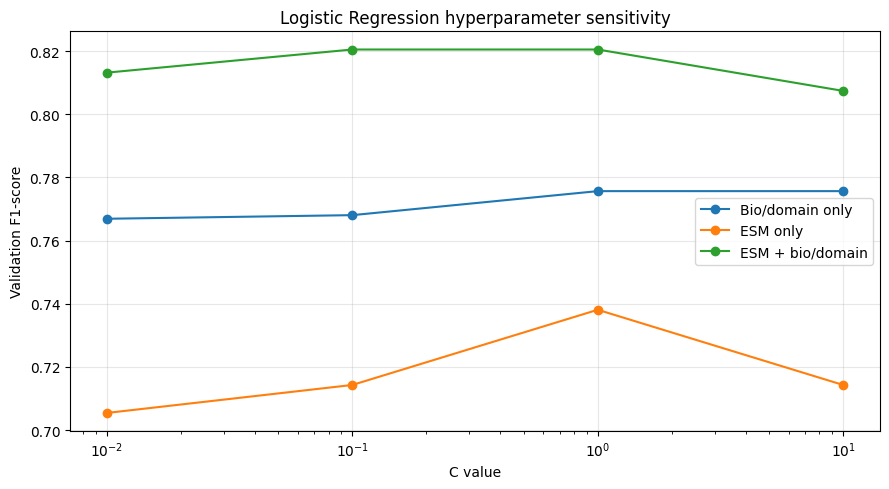

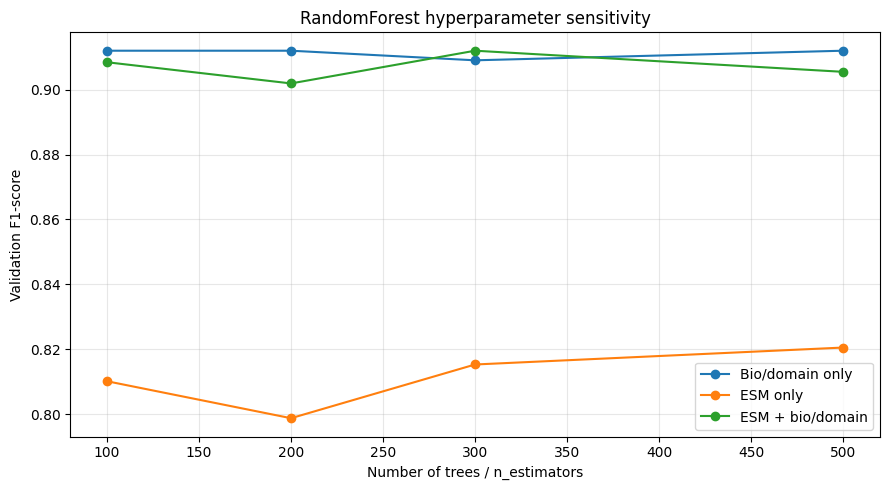

Saved:
/content/logistic_regression_hyperparameter_sensitivity.png
/content/randomforest_hyperparameter_sensitivity.png


In [ ]:
# ============================================================
# 10C. Plot hyperparameter sensitivity results
# ============================================================

# Plot 1: Logistic Regression C values for all feature sets
plt.figure(figsize=(9, 5))

for feature_set_name in feature_sets.keys():
    temp = hyperparam_results_df[
        (hyperparam_results_df["algorithm"] == "LogisticRegression") &
        (hyperparam_results_df["feature_set"] == feature_set_name)
    ].sort_values("hyperparameter_value")

    plt.plot(
        temp["hyperparameter_value"],
        temp["f1_pathogenic"],
        marker="o",
        label=feature_set_name,
    )

plt.xscale("log")
plt.xlabel("C value")
plt.ylabel("Validation F1-score")
plt.title("Logistic Regression hyperparameter sensitivity")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("/content/logistic_regression_hyperparameter_sensitivity.png", dpi=300)
plt.show()


# Plot 2: RandomForest n_estimators values for all feature sets
plt.figure(figsize=(9, 5))

for feature_set_name in feature_sets.keys():
    temp = hyperparam_results_df[
        (hyperparam_results_df["algorithm"] == "RandomForest") &
        (hyperparam_results_df["feature_set"] == feature_set_name)
    ].sort_values("hyperparameter_value")

    plt.plot(
        temp["hyperparameter_value"],
        temp["f1_pathogenic"],
        marker="o",
        label=feature_set_name,
    )

plt.xlabel("Number of trees / n_estimators")
plt.ylabel("Validation F1-score")
plt.title("RandomForest hyperparameter sensitivity")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("/content/randomforest_hyperparameter_sensitivity.png", dpi=300)
plt.show()

print("Saved:")
print("/content/logistic_regression_hyperparameter_sensitivity.png")
print("/content/randomforest_hyperparameter_sensitivity.png")

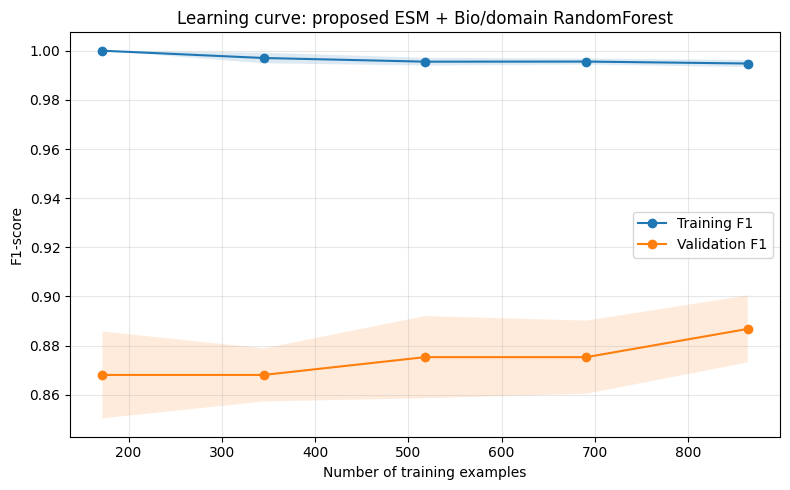

,training_examples,training_f1_mean,training_f1_std,validation_f1_mean,validation_f1_std
0,172,1.000000,0.000000,0.868052,0.017667
1,345,0.997033,0.002148,0.868054,0.010805
2,518,0.995546,0.001576,0.875292,0.016719
3,691,0.995586,0.001231,0.875294,0.014863
4,864,0.994793,0.001444,0.886781,0.013633


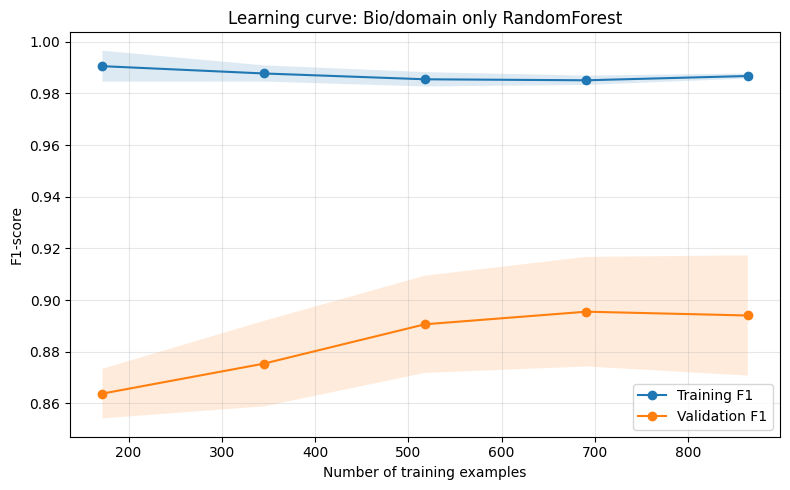

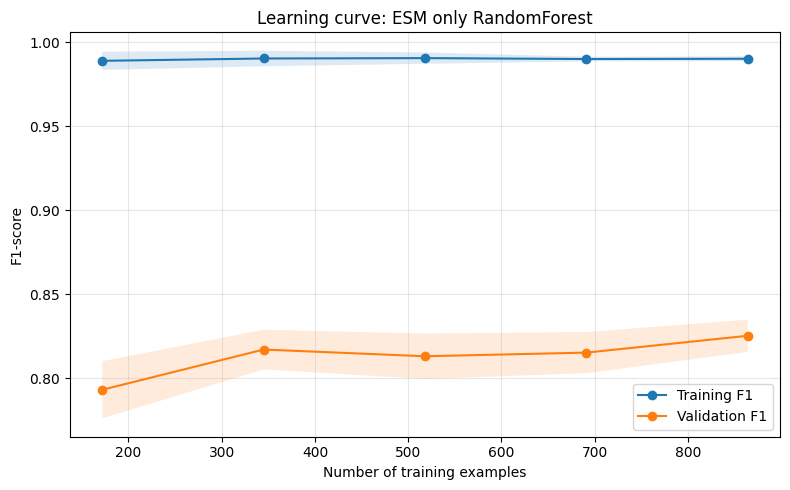

Saved:
/content/learning_curve_proposed_esm_biodomain_rf.png
/content/learning_curve_biodomain_rf.png
/content/learning_curve_esm_rf.png
/content/learning_curve_proposed_esm_biodomain_rf.csv
/content/learning_curve_biodomain_rf.csv
/content/learning_curve_esm_rf.csv


In [ ]:
# ============================================================
# 10D. Learning / convergence curves
# ============================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED,
)

train_sizes = np.linspace(0.2, 1.0, 5)


def plot_learning_curve_for_model(estimator, feature_cols, title, output_path):
    train_sizes_abs, train_scores, val_scores = learning_curve(
        estimator=estimator,
        X=X_train[feature_cols],
        y=y_train,
        train_sizes=train_sizes,
        cv=cv,
        scoring="f1",
        n_jobs=-1,
        shuffle=True,
        random_state=SEED,
    )

    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    val_mean = val_scores.mean(axis=1)
    val_std = val_scores.std(axis=1)

    plt.figure(figsize=(8, 5))

    plt.plot(
        train_sizes_abs,
        train_mean,
        marker="o",
        label="Training F1",
    )

    plt.fill_between(
        train_sizes_abs,
        train_mean - train_std,
        train_mean + train_std,
        alpha=0.15,
    )

    plt.plot(
        train_sizes_abs,
        val_mean,
        marker="o",
        label="Validation F1",
    )

    plt.fill_between(
        train_sizes_abs,
        val_mean - val_std,
        val_mean + val_std,
        alpha=0.15,
    )

    plt.xlabel("Number of training examples")
    plt.ylabel("F1-score")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_path, dpi=300)
    plt.show()

    curve_df = pd.DataFrame({
        "training_examples": train_sizes_abs,
        "training_f1_mean": train_mean,
        "training_f1_std": train_std,
        "validation_f1_mean": val_mean,
        "validation_f1_std": val_std,
    })

    return curve_df


# Proposed model: ESM + Bio/domain RandomForest
proposed_rf_estimator = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("clf", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=SEED,
        n_jobs=-1,
    )),
])

proposed_learning_curve_df = plot_learning_curve_for_model(
    estimator=proposed_rf_estimator,
    feature_cols=all_features,
    title="Learning curve: proposed ESM + Bio/domain RandomForest",
    output_path="/content/learning_curve_proposed_esm_biodomain_rf.png",
)

display(proposed_learning_curve_df)

proposed_learning_curve_df.to_csv(
    "/content/learning_curve_proposed_esm_biodomain_rf.csv",
    index=False,
)


# Optional comparison: Bio/domain only RandomForest
bio_rf_estimator = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("clf", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=SEED,
        n_jobs=-1,
    )),
])

bio_learning_curve_df = plot_learning_curve_for_model(
    estimator=bio_rf_estimator,
    feature_cols=bio_domain_features,
    title="Learning curve: Bio/domain only RandomForest",
    output_path="/content/learning_curve_biodomain_rf.png",
)

bio_learning_curve_df.to_csv(
    "/content/learning_curve_biodomain_rf.csv",
    index=False,
)


# Optional comparison: ESM only RandomForest
esm_rf_estimator = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("clf", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=SEED,
        n_jobs=-1,
    )),
])

esm_learning_curve_df = plot_learning_curve_for_model(
    estimator=esm_rf_estimator,
    feature_cols=esm_features,
    title="Learning curve: ESM only RandomForest",
    output_path="/content/learning_curve_esm_rf.png",
)

esm_learning_curve_df.to_csv(
    "/content/learning_curve_esm_rf.csv",
    index=False,
)

print("Saved:")
print("/content/learning_curve_proposed_esm_biodomain_rf.png")
print("/content/learning_curve_biodomain_rf.png")
print("/content/learning_curve_esm_rf.png")
print("/content/learning_curve_proposed_esm_biodomain_rf.csv")
print("/content/learning_curve_biodomain_rf.csv")
print("/content/learning_curve_esm_rf.csv")

In [ ]:
# ============================================================
# 10E. Download outputs from Colab
# ============================================================

from google.colab import files

files.download("/content/hyperparameter_sensitivity_results.csv")
files.download("/content/logistic_regression_hyperparameter_sensitivity.png")
files.download("/content/randomforest_hyperparameter_sensitivity.png")
files.download("/content/learning_curve_proposed_esm_biodomain_rf.png")
files.download("/content/learning_curve_biodomain_rf.png")
files.download("/content/learning_curve_esm_rf.png")
files.download("/content/learning_curve_proposed_esm_biodomain_rf.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

              precision    recall  f1-score   support

      Benign       0.86      0.59      0.70       111
  Pathogenic       0.84      0.96      0.90       250

    accuracy                           0.84       361
   macro avg       0.85      0.78      0.80       361
weighted avg       0.85      0.84      0.84       361



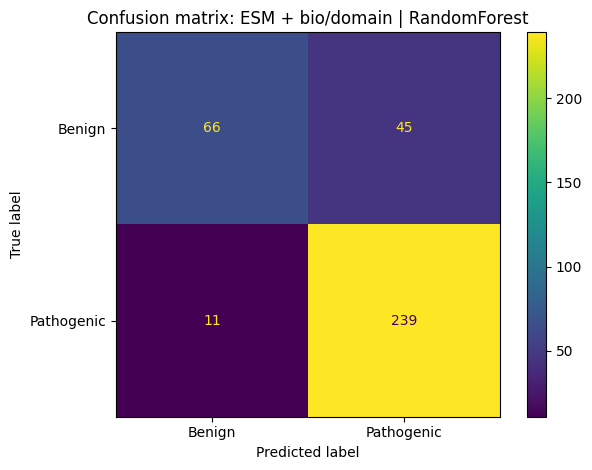

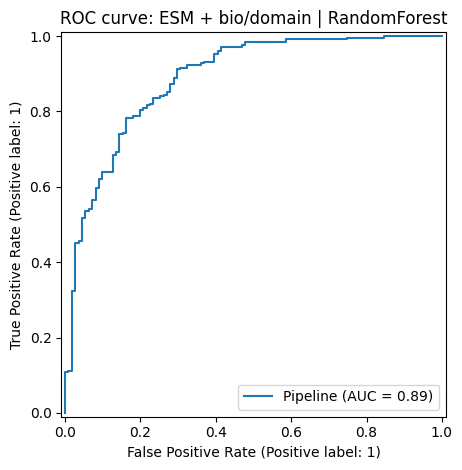

In [ ]:
# ============================================================
# 11. Detailed evaluation of best model
# ============================================================

best_pred = best_model.predict(X_test[best_features])
best_prob = best_model.predict_proba(X_test[best_features])[:, 1]

print(classification_report(
    y_test,
    best_pred,
    target_names=["Benign", "Pathogenic"],
    zero_division=0,
))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_pred,
    display_labels=["Benign", "Pathogenic"],
)
plt.title(f"Confusion matrix: {best_name}")
plt.tight_layout()
plt.savefig("/content/confusion_matrix.png", dpi=200)
plt.show()

RocCurveDisplay.from_estimator(best_model, X_test[best_features], y_test)
plt.title(f"ROC curve: {best_name}")
plt.tight_layout()
plt.savefig("/content/roc_curve.png", dpi=200)
plt.show()

,feature,random_forest_importance,abs_value
1,protein_length,0.116277,0.116277
2,window_length,0.097150,0.097150
0,norm_position,0.068145,0.068145
19,esm_site_cosine_distance,0.063761,0.063761
17,esm_mean_cosine_distance,0.062849,0.062849
21,esm_site_abs_delta_mean,0.062676,0.062676
3,blosum62,0.058558,0.058558
16,uniprot_feature_count,0.056810,0.056810
18,esm_mean_l2_distance,0.056267,0.056267
20,esm_site_l2_distance,0.056131,0.056131


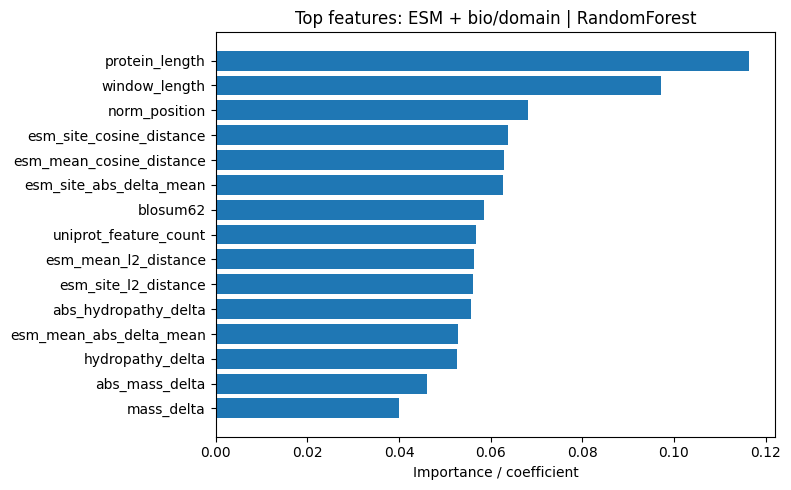

In [ ]:
# ============================================================
# 12. Interpretability: coefficients or feature importance
# ============================================================

def get_feature_importance_or_coefficients(model_entry):
    model = model_entry["model"]
    cols = model_entry["features"]

    clf = model.named_steps["clf"]

    if hasattr(clf, "feature_importances_"):
        values = clf.feature_importances_
        kind = "random_forest_importance"
    elif hasattr(clf, "coef_"):
        values = clf.coef_[0]
        kind = "logistic_regression_coefficient"
    else:
        return None

    out = pd.DataFrame({
        "feature": cols,
        kind: values,
        "abs_value": np.abs(values),
    }).sort_values("abs_value", ascending=False)

    return out


importance_df = get_feature_importance_or_coefficients(trained_models[best_name])
if importance_df is not None:
    display(importance_df.head(20))
    importance_df.to_csv("/content/best_model_feature_importance.csv", index=False)

    top = importance_df.head(15).iloc[::-1]
    plt.figure(figsize=(8, 5))
    plt.barh(top["feature"], top.iloc[:, 1])
    plt.title(f"Top features: {best_name}")
    plt.xlabel("Importance / coefficient")
    plt.tight_layout()
    plt.savefig("/content/top_features.png", dpi=200)
    plt.show()
else:
    print("No importance/coefficient available for this model.")

In [ ]:
# ============================================================
# 13. VUS-style case study
# ============================================================

# Sample VUS-like variants. These are not used for training.
if len(vus_raw) > 0:
    vus_sample = vus_raw.sample(
        n=min(len(vus_raw), MAX_VUS_CASE_STUDY_VARIANTS),
        random_state=SEED,
    )

    vus_verified = annotate_variants_with_sequence_and_uniprot(
        vus_sample,
        protein_info,
        radius=WINDOW_RADIUS,
    )

    print("Verified VUS-like variants:", len(vus_verified))

    if len(vus_verified) > 0:
        vus_features = add_esm_change_features(vus_verified, cache_prefix="/content/vus")

        vus_features["predicted_pathogenic_probability"] = best_model.predict_proba(
            vus_features[best_features]
        )[:, 1]

        vus_features["predicted_class"] = np.where(
            vus_features["predicted_pathogenic_probability"] >= 0.5,
            "Predicted pathogenic-like",
            "Predicted benign-like",
        )

        case_study_cols = [
            "GeneSymbol",
            "Name",
            "ClinicalSignificance",
            "wt_aa",
            "position",
            "mut_aa",
            "predicted_pathogenic_probability",
            "predicted_class",
            "in_domain_like_feature",
            "in_active_or_binding_feature",
            "covering_feature_types",
            "PhenotypeList",
        ]
        case_study_cols = [c for c in case_study_cols if c in vus_features.columns]

        vus_ranked = vus_features.sort_values(
            "predicted_pathogenic_probability",
            ascending=False,
        )[case_study_cols]

        display(vus_ranked.head(20))
        vus_ranked.to_csv("/content/vus_case_study_predictions.csv", index=False)
        print("Saved /content/vus_case_study_predictions.csv")
    else:
        print("No VUS-like variants survived canonical sequence verification.")
else:
    print("No VUS-like candidates found in the selected genes.")

Verifying sequence positions:   0%|          | 0/60 [00:00<?, ?it/s]

Kept variants: 60
Dropped due to WT mismatch: 0
Dropped due to out-of-range position: 0
Verified VUS-like variants: 60


ESM embedding batches:   0%|          | 0/15 [00:00<?, ?it/s]

Saved: /content/vus_with_esm_features.csv


,GeneSymbol,Name,ClinicalSignificance,wt_aa,position,mut_aa,predicted_pathogenic_probability,predicted_class,in_domain_like_feature,in_active_or_binding_feature,covering_feature_types,PhenotypeList
39,PTEN,NM_000314.8(PTEN):c.299T>C (p.Leu100Pro),Uncertain significance,L,100,P,0.965655,Predicted pathogenic-like,1,0,Chain;Domain;Helix;Natural variant,PTEN hamartoma tumor syndrome
18,PAH,NM_000277.3(PAH):c.1194A>C (p.Lys398Asn),Uncertain significance,K,398,N,0.920964,Predicted pathogenic-like,0,0,Chain;Helix,Phenylketonuria
13,LDLR,NM_000527.5(LDLR):c.1474G>T (p.Asp492Tyr),Conflicting classifications of pathogenicity,D,492,Y,0.884735,Predicted pathogenic-like,1,0,Beta strand;Chain;Natural variant;Repeat;Topol...,not provided|Familial hypercholesterolemia
5,CFTR,NM_000492.4(CFTR):c.3689T>G (p.Ile1230Ser),Uncertain significance,I,1230,S,0.863077,Predicted pathogenic-like,1,0,Alternative sequence;Beta strand;Chain;Domain;...,CFTR-related disorder
54,CFTR,NM_000492.4(CFTR):c.89A>C (p.Gln30Pro),Uncertain significance,Q,30,P,0.812705,Predicted pathogenic-like,0,0,Chain;Topological domain,Cystic fibrosis
27,CFTR,NM_000492.4(CFTR):c.2755T>A (p.Tyr919Asn),Uncertain significance,Y,919,N,0.798835,Predicted pathogenic-like,1,0,Alternative sequence;Chain;Domain;Helix;Natura...,Cystic fibrosis|CFTR-related disorder
16,G6PD,NM_001360016.2(G6PD):c.937G>A (p.Asp313Asn),Uncertain significance,D,313,N,0.731047,Predicted pathogenic-like,0,0,Beta strand;Chain,"Anemia, nonspherocytic hemolytic, due to G6PD ..."
55,BRCA2,NM_000059.4(BRCA2):c.193C>T (p.Pro65Ser),Uncertain significance,P,65,S,0.730389,Predicted pathogenic-like,1,0,Chain;Region,not specified|Hereditary breast ovarian cancer...
17,BRCA1,NM_007294.4(BRCA1):c.5085T>A (p.Phe1695Leu),Conflicting classifications of pathogenicity,F,1695,L,0.662172,Predicted pathogenic-like,1,0,Alternative sequence;Beta strand;Chain;Domain;...,"Breast-ovarian cancer, familial, susceptibilit..."
8,BRCA2,NM_000059.4(BRCA2):c.7844T>A (p.Ile2615Asn),Uncertain significance,I,2615,N,0.653796,Predicted pathogenic-like,1,0,Chain;Region,Hereditary breast ovarian cancer syndrome


Saved /content/vus_case_study_predictions.csv


In [ ]:
# ============================================================
# 14. Save final outputs
# ============================================================

features_df.to_csv("/content/final_training_features.csv", index=False)

print("Saved files:")
print("/content/final_training_features.csv")
print("/content/model_comparison_results.csv")
print("/content/confusion_matrix.png")
print("/content/roc_curve.png")
print("/content/top_features.png, if available")
print("/content/vus_case_study_predictions.csv, if VUS variants were available")

#In Colab, uncomment these lines if you want to download the outputs:
# from google.colab import files
# files.download("/content/final_training_features.csv")
# files.download("/content/model_comparison_results.csv")
# files.download("/content/confusion_matrix.png")
# files.download("/content/roc_curve.png")
# files.download("/content/vus_case_study_predictions.csv")

Saved files:
/content/final_training_features.csv
/content/model_comparison_results.csv
/content/confusion_matrix.png
/content/roc_curve.png
/content/top_features.png, if available
/content/vus_case_study_predictions.csv, if VUS variants were available


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>